In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['axes.unicode_minus'] = False # -(마이너스) 기호 깨짐 방지
plt.rcParams['font.family'] = 'Malgun Gothic'

%matplotlib inline

In [36]:
df = pd.read_csv('data/flight.csv')
df.head(3)

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956


In [37]:
# 결측지가 있는지 확인하기

print(df.isna().sum()) #각 컬럼별 결측지의 개수를 파악하기
print()
print(f'전체 데이터의 결측치 개수 : {df.isna().sum().sum()}') #각 컬럼별 결측지의 개수를 파악하기


Unnamed: 0          0
airline             0
flight              0
source_city         0
departure_time      0
stops               0
arrival_time        0
destination_city    0
class               0
duration            0
days_left           0
price               0
dtype: int64

전체 데이터의 결측치 개수 : 0


In [38]:
# 필요있는 컬럼 삭제하기
df = df.drop('Unnamed: 0', axis=1)
df.head(3)

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956


In [39]:
# 가장 마지막 데이터 3개
df.tail(3)

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
300150,Vistara,UK-832,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49,79099
300151,Vistara,UK-828,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49,81585
300152,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,81585


In [40]:
# 타입이 object인 컬럼들만 추리기
cols = df.select_dtypes('object').columns
# 각 컬럼별의 유니크한 값들의 개수를 확인하기 (내림차순 정렬)
df[cols].nunique().sort_values(ascending=False)

flight              1561
airline                6
source_city            6
departure_time         6
arrival_time           6
destination_city       6
stops                  3
class                  2
dtype: int64

In [41]:
df = df.drop(columns=['flight'])
df.head(3)

,airline,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956


In [42]:
# one-hot encoding 하기

df_copy = pd.get_dummies(df, drop_first=True, dtype=int)
df_copy.head(3)

,duration,days_left,price,airline_Air_India,airline_GO_FIRST,airline_Indigo,airline_SpiceJet,airline_Vistara,source_city_Chennai,source_city_Delhi,...,arrival_time_Evening,arrival_time_Late_Night,arrival_time_Morning,arrival_time_Night,destination_city_Chennai,destination_city_Delhi,destination_city_Hyderabad,destination_city_Kolkata,destination_city_Mumbai,class_Economy
0,2.17,1,5953,0,0,0,1,0,0,1,...,0,0,0,1,0,0,0,0,1,1
1,2.33,1,5953,0,0,0,1,0,0,1,...,0,0,1,0,0,0,0,0,1,1
2,2.17,1,5956,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,1,1


In [43]:
from sklearn.model_selection import train_test_split

# 타겟 데이터를 분리한다.
x = df_copy.drop(columns='price')
y = df_copy['price']

print(x.shape,y.shape)

(300153, 30) (300153,)


In [44]:
# 훈령용 데이터와 검증용 데이터를 분리한다.
X_train, X_test, y_train, y_test = train_test_split(
    x,y,
    test_size=0.2,
    random_state=4
)
print(f'X_train:{X_train.shape}, X_test:{X_test.shape}')
print(f'X_train:{y_train.shape}, X_test:{y_test.shape}')

X_train:(240122, 30), X_test:(60031, 30)
X_train:(240122,), X_test:(60031,)


In [45]:
from sklearn.linear_model import LinearRegression

# 선형회귀 객체 생성
lr = LinearRegression()

# 학습 데이터를 제공하여 학습 모델을 생성한다.
model = lr.fit(X_train,y_train)

s_coef = pd.Series(model.coef_, index=x.columns)
s_coef.sort_values(key=abs, ascending=False)

class_Economy                  -44930.843563
stops_zero                      -7593.564275
airline_Vistara                  4062.141224
airline_SpiceJet                 2288.437860
airline_Indigo                   2109.822882
stops_two_or_more                2096.140216
source_city_Hyderabad           -1707.344001
airline_GO_FIRST                 1693.289651
destination_city_Hyderabad      -1692.741448
departure_time_Late_Night        1676.622343
source_city_Kolkata              1589.919562
destination_city_Delhi          -1542.153906
source_city_Delhi               -1420.199206
destination_city_Kolkata         1400.600803
arrival_time_Night               1118.496272
arrival_time_Late_Night           943.953376
arrival_time_Evening              916.055026
departure_time_Morning            869.530540
departure_time_Early_Morning      845.438165
arrival_time_Early_Morning       -784.071885
departure_time_Evening            756.329789
departure_time_Night              683.485088
arrival_ti

In [46]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

# 예측 (훈련하지 않은 X 데이터를 주입하여 예측 결과를 얻는다)

y_pred = model.predict(X_test)

print(f'MAE: {mean_absolute_error(y_test, y_pred):.3f}')
print(f'MS: {mean_squared_error(y_test, y_pred):.3f}')
print(f'RMS: {root_mean_squared_error(y_test, y_pred):.3f}')
print(f'R2: {r2_score(y_test, y_pred):.3f}')



MAE: 4537.503
MS: 44730548.894
RMS: 6688.090
R2: 0.913


In [47]:
mae = mean_absolute_error(y_test, y_pred)
price = df['price'].mean()

print(mae / price)

0.21721288570135713


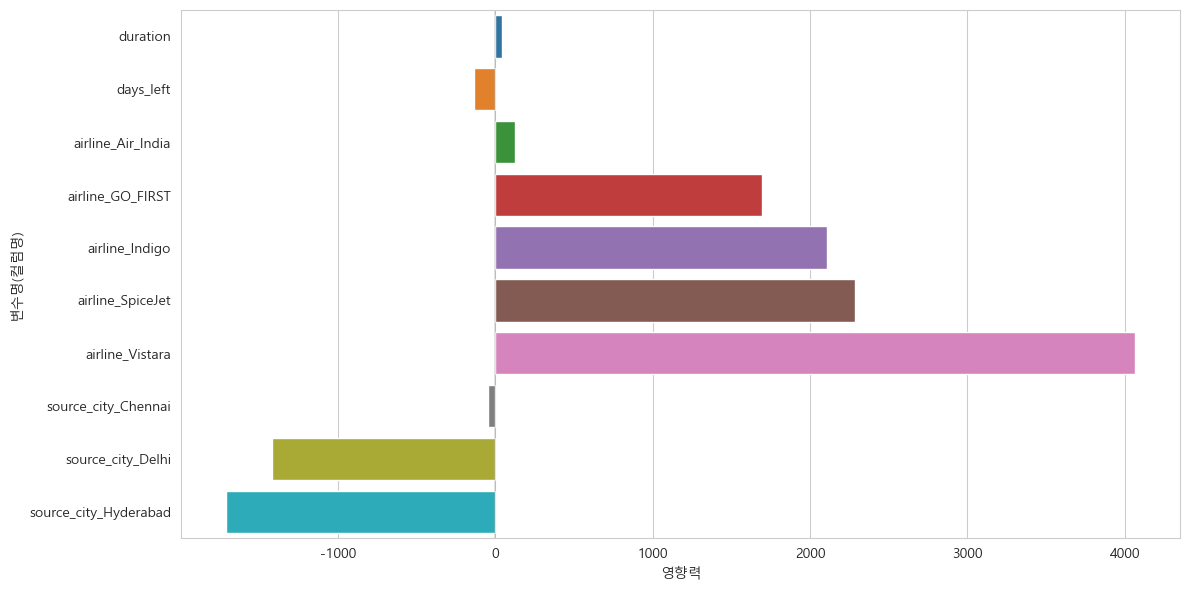

In [50]:
s_coef_10 = s_coef.head(10)
plt.figure(figsize=(12,6))
# seaborn를 이용하여 막대그래프 그리기
sns.barplot(
    x= s_coef_10.values,
    y= s_coef_10.index,
    hue= s_coef_10.index,
    legend=False # y축의 값이 legend나 마찬가지이므로 안보여줘도 됨
)
plt.axvline(0,color='gray',linewidth='0.3')
plt.xlabel('영향력')
plt.ylabel('변수명(컬럼명)')
plt.tight_layout()
plt.show()